In [1]:
import pandas as pd
from support_research import *
import matplotlib.pyplot as plt


In [2]:
bitcoin_data = pd.read_csv('../../data/bronze/spot_ohlcv_1d__cryptoquant_agg__BTCUSD.csv')[::-1].reset_index(drop=True)
eth_data = pd.read_csv('../../data/bronze/spot_ohlcv_1d__cryptoquant_agg__ETHUSD.csv')[::-1].reset_index(drop=True)
xrp_data = pd.read_csv('../../data/bronze/spot_ohlcv_1d__cryptoquant_agg__XRPUSD.csv')[::-1].reset_index(drop=True)
bitcoin_data['return'] = bitcoin_data['Close'].pct_change()
bitcoin_data['target'] = bitcoin_data['return'].shift(-1)

C:\Users\MrlJu\AppData\Local\Temp\ipykernel_23596\1173905136.py:4: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Call ffill before calling pct_change to retain current behavior and silence this warning.
  bitcoin_data['return'] = bitcoin_data['Close'].pct_change()


In [ ]:
bitcoin_data['signal'] = bitcoin_data['return'].rolling(window=1000).apply(lambda x: applicate_mean(x, window=10, horizon=1, k=20, n=10))
bitcoin_data['signal_std'] = bitcoin_data['return'].rolling(window=1000).apply(lambda x: applicate_std(x, window=10, horizon=1, k=20, n=10))
bitcoin_data['filter'] = np.where(abs(bitcoin_data['signal'] / bitcoin_data['signal_std']) > 1, 1, np.nan)
bitcoin_data['filtered_signal'] = bitcoin_data['signal'] * bitcoin_data['filter']

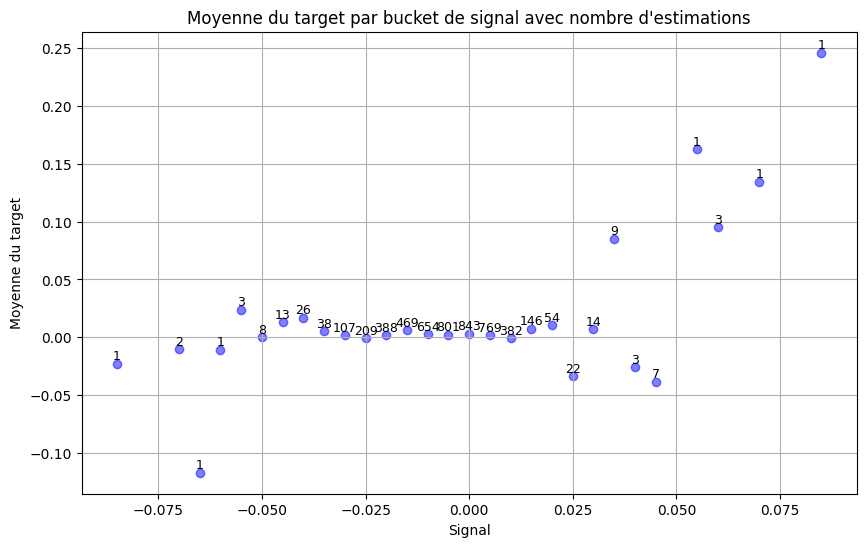

In [ ]:
import matplotlib.pyplot as plt

# Créer les buckets
bitcoin_data['signal_bucket'] = round(bitcoin_data['signal'] / 0.005) * 0.005  # bucket de 0.5%
trace = bitcoin_data.groupby('signal_bucket')['target'].mean()
counts = bitcoin_data.groupby('signal_bucket')['target'].count()  # nombre d'estimations par bucket

plt.figure(figsize=(10, 6))
plt.scatter(trace.index, trace.values, alpha=0.5, color='blue')

# Ajouter le nombre d'estimations au-dessus des points
for x, y, c in zip(trace.index, trace.values, counts):
    plt.text(x, y + 0.001, str(c), ha='center', va='bottom', fontsize=9)

plt.xlabel('Signal')
plt.ylabel('Moyenne du target')
plt.title('Moyenne du target par bucket de signal avec nombre d\'estimations')
plt.grid(True)
plt.show()


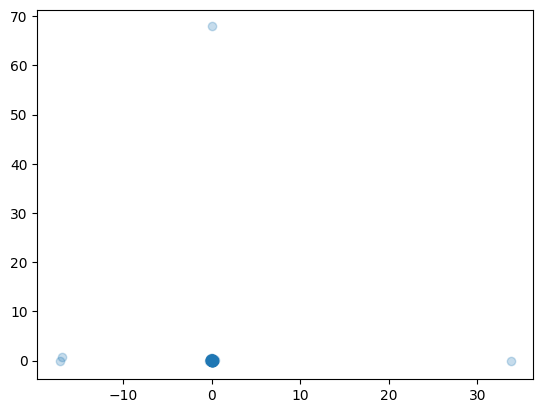

In [8]:
plt.scatter(bitcoin_data['signal'], bitcoin_data['return'].shift(-1), alpha=0.25)